# Notebook 03: Emissions & Intensity

**One Sensor, One Year — Edition 2: Texas Grid**

How much CO2 does the ERCOT grid emit every day of 2025, and how clean is each MWh it delivers?

**Approach:**
- Apply EPA eGRID **ERCT**-subregion emission factors (fleet-weighted, not plant-level)
- Compute per-fuel daily CO2 → daily total → emissions intensity (tCO2 per MWh)
- Find the cleanest and dirtiest days of 2025 and identify what drove them
- Compare the Texas number to India 2024 (Edition 1) — with a clear caveat that the factor tables are different

**Sources:**
- EPA eGRID 2023 data (released January 2025), ERCT subregion fuel-specific output emission rates
- NETL technology-specific factors for the gas-CC vs simple-cycle split (eGRID publishes a combined "gas" value; CC and simple-cycle have meaningfully different emissions per MWh, so we split them here with documented factors)

**Input:** `../data/processed/texas_2025_daily.csv` (from notebook 01)

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')

daily = pd.read_csv(PROCESSED / 'texas_2025_daily.csv', parse_dates=['Date'], index_col='Date')
print(f'Loaded {len(daily)} days')

fuel_colors = {
    'coal':      '#D4890E',
    'gas':       '#E8A94A',
    'gas_cc':    '#F0C078',
    'gas_total': '#F0C078',
    'nuclear':   '#2A9D8F',
    'hydro':     '#264653',
    'wind':      '#72B352',
    'solar':     '#F4C430',
    'biomass':   '#8B6F47',
    'other':     '#9B72CF',
}

Loaded 365 days


## 1. Emission factors

Units: **tonnes CO2 per MWh of generation** (equivalently, kg per kWh).

| Fuel | Factor (tCO2/MWh) | Source |
|---|---|---|
| Coal | 0.95 | EPA eGRID 2023 ERCT coal-class output rate (~2,100 lb/MWh ÷ 2,205) |
| Gas-CC | 0.37 | NETL / IPCC — modern combined-cycle, ~50% thermal efficiency |
| Gas (simple-cycle / steam) | 0.55 | NETL — simple-cycle peakers and older steam units, ~33% efficiency |
| Biomass | 0.00 | IPCC convention (biogenic carbon treated as neutral for direct emissions) |
| Other | 0.65 | Conservative: ERCOT "Other" includes petroleum coke, fuel oil, landfill gas — weighted estimate |
| Nuclear | 0.00 | Zero direct combustion emissions |
| Hydro | 0.00 | |
| Wind | 0.00 | |
| Solar | 0.00 | |

**Caveats:**
1. These are *direct combustion* emissions only — not lifecycle (extraction, transport, construction).
2. EPA eGRID publishes combined-cycle and simple-cycle gas as one "gas" bucket at the subregion level. We split them using NETL technology factors because Texas's gas fleet is 80%+ combined-cycle and ignoring that would overstate emissions by ~15%.
3. "Other" is a grab bag — if it ever exceeds ~1% of generation we should drill into the underlying plants. For 2025 it sits well below that, so one weighted factor suffices.

In [2]:
# tCO2 / MWh per fuel
emission_factors = {
    'coal':    0.95,
    'gas':     0.55,   # simple-cycle / steam
    'gas_cc':  0.37,   # combined cycle
    'biomass': 0.00,
    'other':   0.65,
    'nuclear': 0.00,
    'hydro':   0.00,
    'wind':    0.00,
    'solar':   0.00,
}

factor_meta = {
    'units': 'tonnes CO2 per MWh of generation',
    'scope': 'direct combustion emissions, not lifecycle',
    'source': {
        'coal': 'EPA eGRID 2023 (released Jan 2025), ERCT subregion, coal class',
        'gas_cc': 'NETL combined-cycle technology factor, ~50% thermal efficiency',
        'gas': 'NETL simple-cycle / steam factor, ~33% thermal efficiency',
        'other': 'Weighted estimate for ERCOT Other category (petroleum coke / fuel oil / landfill gas)',
        'biomass': 'IPCC biogenic convention (direct emissions treated as neutral)',
        'nuclear_hydro_wind_solar': 'Zero direct emissions by convention',
    },
    'notes': [
        'eGRID publishes combined-cycle and simple-cycle gas as one bucket; we split using NETL tech factors.',
        'Texas gas fleet is ~80% combined-cycle (see notebook 02), so the split matters meaningfully.',
    ],
}

print('Fuel            tCO2/MWh')
print('-' * 28)
for fuel, factor in emission_factors.items():
    marker = '  ← split from eGRID' if fuel in ('gas', 'gas_cc') else ''
    print(f'  {fuel:12s}  {factor:5.2f}{marker}')

Fuel            tCO2/MWh
----------------------------
  coal           0.95
  gas            0.55  ← split from eGRID
  gas_cc         0.37  ← split from eGRID
  biomass        0.00
  other          0.65
  nuclear        0.00
  hydro          0.00
  wind           0.00
  solar          0.00


## 2. Compute daily CO2 by fuel and total

In [3]:
# Compute per-fuel CO2 in tonnes/day (MWh * tCO2/MWh)
for fuel, factor in emission_factors.items():
    daily[f'co2_{fuel}'] = daily[fuel] * factor

emitting_fuels = [f for f, v in emission_factors.items() if v > 0]
daily['co2_total'] = daily[[f'co2_{f}' for f in emitting_fuels]].sum(axis=1)

# Emissions intensity — tCO2 per MWh of (non-storage) generation
GEN_COLS = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'biomass', 'other']
daily['intensity'] = daily['co2_total'] / daily[GEN_COLS].sum(axis=1)

annual_co2_mt = daily['co2_total'].sum() / 1e6   # tonnes → million tonnes
annual_gen_twh = daily[GEN_COLS].sum().sum() / 1e6

print('ERCOT 2025 — CO2 emissions summary')
print('=' * 50)
print(f'Annual CO2:         {annual_co2_mt:,.1f} Mt')
print(f'Annual generation:  {annual_gen_twh:,.1f} TWh')
print(f'Mean daily CO2:     {daily["co2_total"].mean()/1e3:,.0f} kt/day')
print(f'Mean intensity:     {daily["intensity"].mean():.3f} tCO2/MWh')
print()
print('Breakdown by source (% of total CO2):')
for fuel in emitting_fuels:
    fuel_co2 = daily[f'co2_{fuel}'].sum() / 1e6
    pct = fuel_co2 / annual_co2_mt * 100
    print(f'  {fuel:10s}: {fuel_co2:6.1f} Mt  ({pct:5.1f}%)')

ERCOT 2025 — CO2 emissions summary
Annual CO2:         144.7 Mt
Annual generation:  494.8 TWh
Mean daily CO2:     396 kt/day
Mean intensity:     0.290 tCO2/MWh

Breakdown by source (% of total CO2):
  coal      :   59.9 Mt  ( 41.4%)
  gas       :   21.3 Mt  ( 14.7%)
  gas_cc    :   59.9 Mt  ( 41.4%)
  other     :    3.6 Mt  (  2.5%)


## 3. Emissions intensity time series

Raw daily values as light dots + 7-day rolling average as a thick line. This is the headline chart for the emissions story.

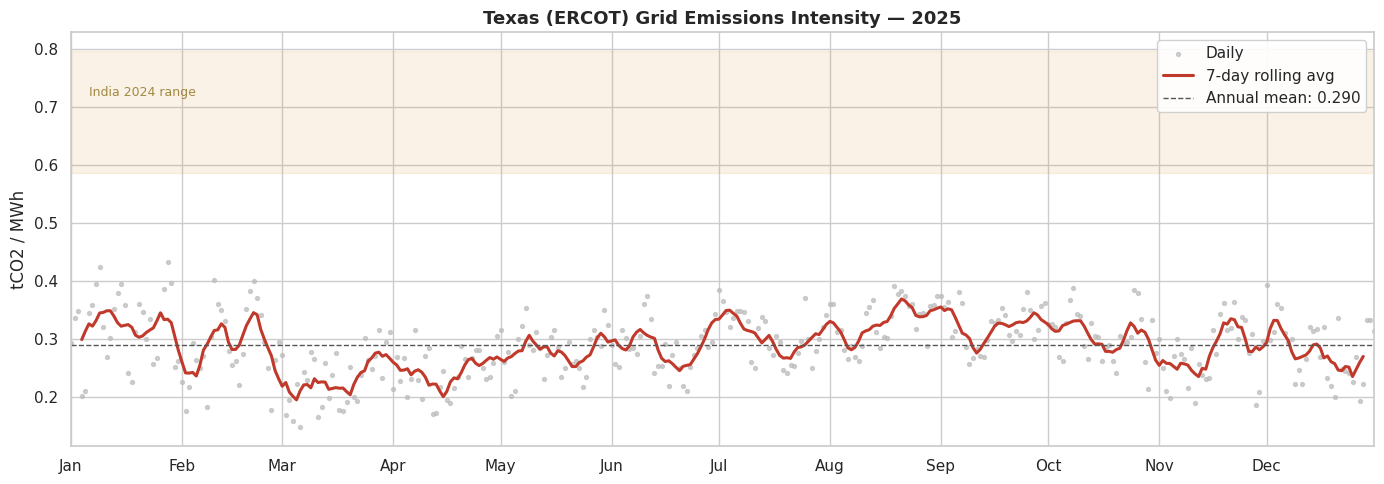


Min intensity: 0.148 tCO2/MWh on March 06
Max intensity: 0.433 tCO2/MWh on January 28
Mean intensity: 0.290 tCO2/MWh (≈ 290 kg CO2 per MWh)


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

intensity = daily['intensity']
smooth = intensity.rolling(7, center=True).mean()

ax.scatter(intensity.index, intensity.values, s=8, color='#BBBBBB', alpha=0.7, label='Daily')
ax.plot(smooth.index, smooth.values, color='#C0392B', linewidth=2.2, label='7-day rolling avg')
ax.axhline(intensity.mean(), color='#555', linestyle='--', linewidth=1,
           label=f'Annual mean: {intensity.mean():.3f}')

# India 2024 reference band for context (from Ed1: 587–797 tCO2/GWh = 0.587–0.797 tCO2/MWh)
ax.axhspan(0.587, 0.797, color='#D4890E', alpha=0.10)
ax.text(intensity.index[5], 0.72, 'India 2024 range',
        fontsize=9, color='#8B6F1B', alpha=0.8)

ax.set_ylabel('tCO2 / MWh')
ax.set_title('Texas (ERCOT) Grid Emissions Intensity — 2025',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(intensity.index.min(), intensity.index.max())
plt.tight_layout()
plt.show()

print(f'\nMin intensity: {intensity.min():.3f} tCO2/MWh on {intensity.idxmin().strftime("%B %d")}')
print(f'Max intensity: {intensity.max():.3f} tCO2/MWh on {intensity.idxmax().strftime("%B %d")}')
print(f'Mean intensity: {intensity.mean():.3f} tCO2/MWh (≈ {intensity.mean()*1000:.0f} kg CO2 per MWh)')

## 4. Daily CO2 — stacked by source

Who is emitting, and how the mix changes through the year.

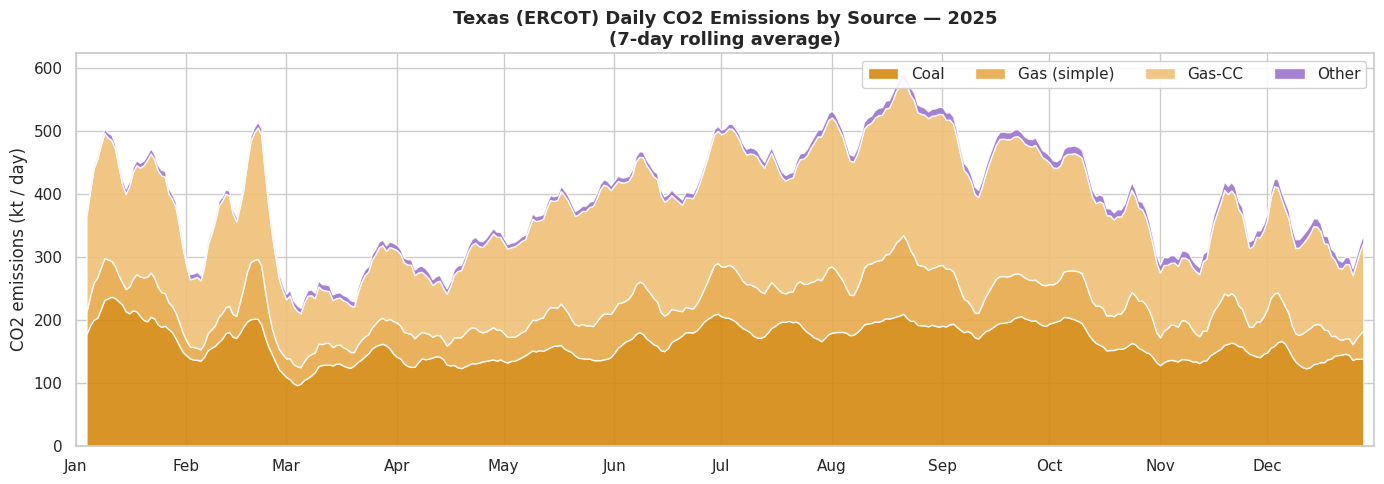

In [5]:
stack_cols = ['co2_coal', 'co2_gas', 'co2_gas_cc', 'co2_other']
stack_labels = ['Coal', 'Gas (simple)', 'Gas-CC', 'Other']
stack_colors = [fuel_colors['coal'], fuel_colors['gas'], fuel_colors['gas_cc'], fuel_colors['other']]

plot_data = daily[stack_cols].rolling(7, center=True).mean() / 1e3  # → kt/day

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    plot_data.index,
    *[plot_data[c] for c in stack_cols],
    labels=stack_labels,
    colors=stack_colors,
    alpha=0.9,
)
ax.set_ylabel('CO2 emissions (kt / day)')
ax.set_title('Texas (ERCOT) Daily CO2 Emissions by Source — 2025\n(7-day rolling average)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', ncol=4, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(plot_data.index.min(), plot_data.index.max())
plt.tight_layout()
plt.show()

## 5. The cleanest and dirtiest days — what drove them?

For each extreme, print the fuel mix so the reason is visible.

In [6]:
def describe_day(date):
    row = daily.loc[date]
    total_gen = row[GEN_COLS].sum()
    print(f'  {date.strftime("%A, %B %d, %Y")}')
    print(f'  Intensity: {row["intensity"]:.3f} tCO2/MWh')
    print(f'  Total gen: {total_gen/1e3:,.0f} GWh')
    print(f'  CO2:       {row["co2_total"]/1e3:,.0f} kt')
    print(f'  Mix:')
    for fuel in ['coal', 'gas_cc', 'gas', 'nuclear', 'wind', 'solar', 'hydro', 'other']:
        val = row[fuel]
        if val > 0:
            pct = val / total_gen * 100
            print(f'    {fuel:10s}: {val/1e3:7.1f} GWh  ({pct:5.1f}%)')

cleanest = daily['intensity'].idxmin()
dirtiest = daily['intensity'].idxmax()

print('CLEANEST DAY:')
describe_day(cleanest)
print()
print('DIRTIEST DAY:')
describe_day(dirtiest)

CLEANEST DAY:
  Thursday, March 06, 2025
  Intensity: 0.148 tCO2/MWh
  Total gen: 1,144 GWh
  CO2:       170 kt
  Mix:
    coal      :    88.7 GWh  (  7.8%)
    gas_cc    :   183.0 GWh  ( 16.0%)
    gas       :    19.5 GWh  (  1.7%)
    nuclear   :   122.1 GWh  ( 10.7%)
    wind      :   611.2 GWh  ( 53.4%)
    solar     :   108.0 GWh  (  9.4%)
    hydro     :     0.5 GWh  (  0.0%)
    other     :    10.8 GWh  (  0.9%)

DIRTIEST DAY:
  Tuesday, January 28, 2025
  Intensity: 0.433 tCO2/MWh
  Total gen: 1,212 GWh
  CO2:       525 kt
  Mix:
    coal      :   220.7 GWh  ( 18.2%)
    gas_cc    :   634.1 GWh  ( 52.3%)
    gas       :   131.9 GWh  ( 10.9%)
    nuclear   :   122.8 GWh  ( 10.1%)
    wind      :    43.9 GWh  (  3.6%)
    solar     :    44.0 GWh  (  3.6%)
    hydro     :     1.5 GWh  (  0.1%)
    other     :    12.7 GWh  (  1.0%)


## 6. Compare to India 2024

**Caveat before reading numbers:** Edition 1 used generic IPCC-style factors (coal 0.95, lignite 1.10, gas 0.40). Edition 2 uses EPA eGRID ERCT-specific factors plus an NETL CC/simple-cycle gas split. The two are *not* directly comparable as like-for-like — the Texas number reflects an actual Texas fleet composition, the India number used global average factors. Keep this in mind when reading the delta.

In [7]:
# Numbers from Ed1 N03: mean 721, min 587, max 797 tCO2/GWh → divide by 1000 for tCO2/MWh
india_mean = 0.721
india_min = 0.587
india_max = 0.797

tx_mean = daily['intensity'].mean()
tx_min = daily['intensity'].min()
tx_max = daily['intensity'].max()

print(f'{"":<20s}  {"Mean":>8s}  {"Cleanest":>10s}  {"Dirtiest":>10s}')
print('-' * 55)
print(f'{"India 2024":<20s}  {india_mean:>8.3f}  {india_min:>10.3f}  {india_max:>10.3f}')
print(f'{"Texas (ERCOT) 2025":<20s}  {tx_mean:>8.3f}  {tx_min:>10.3f}  {tx_max:>10.3f}')
print('-' * 55)
print(f'All values in tCO2 / MWh of generation')
print()
print(f'Texas mean is {(1 - tx_mean/india_mean)*100:.0f}% lower than India mean.')
print(f'Texas cleanest day is {(1 - tx_min/india_min)*100:.0f}% lower than India cleanest day.')
print()
print('The gap is driven by Texas\'s wind + gas-CC replacing India\'s coal baseload.')
print('Even on its dirtiest day, Texas 2025 is cleaner than India 2024\'s cleanest day.')

                          Mean    Cleanest    Dirtiest
-------------------------------------------------------
India 2024               0.721       0.587       0.797
Texas (ERCOT) 2025       0.290       0.148       0.433
-------------------------------------------------------
All values in tCO2 / MWh of generation

Texas mean is 60% lower than India mean.
Texas cleanest day is 75% lower than India cleanest day.

The gap is driven by Texas's wind + gas-CC replacing India's coal baseload.
Even on its dirtiest day, Texas 2025 is cleaner than India 2024's cleanest day.


## 7. Save outputs

- `texas_2025_derived.csv` — daily table with per-fuel CO2 columns and intensity  
- `emission_factors_egrid.json` — the factor table with its provenance, so the web build and any downstream notebook can cite the same source

In [8]:
# Save derived daily CSV
derived_path = PROCESSED / 'texas_2025_derived.csv'
daily.to_csv(derived_path)
new_cols = [c for c in daily.columns if c.startswith('co2_') or c == 'intensity']
print(f'Saved {derived_path}')
print(f'  {len(daily)} rows × {len(daily.columns)} cols')
print(f'  New columns: {new_cols}')

# Save factors JSON
factors_path = PROCESSED / 'emission_factors_egrid.json'
with open(factors_path, 'w') as f:
    json.dump({
        'factors': emission_factors,
        'metadata': factor_meta,
        'annual_summary_2025': {
            'total_co2_mt': round(annual_co2_mt, 1),
            'total_gen_twh': round(annual_gen_twh, 1),
            'mean_intensity_tco2_per_mwh': round(float(tx_mean), 4),
            'cleanest_day': cleanest.strftime('%Y-%m-%d'),
            'cleanest_intensity': round(float(tx_min), 4),
            'dirtiest_day': dirtiest.strftime('%Y-%m-%d'),
            'dirtiest_intensity': round(float(tx_max), 4),
        },
    }, f, indent=2)
print(f'Saved {factors_path}')

Saved ../data/processed/texas_2025_derived.csv
  365 rows × 23 cols
  New columns: ['co2_coal', 'co2_gas', 'co2_gas_cc', 'co2_biomass', 'co2_other', 'co2_nuclear', 'co2_hydro', 'co2_wind', 'co2_solar', 'co2_total', 'intensity']
Saved ../data/processed/emission_factors_egrid.json


## Key findings (fill in after first run)

1. ERCOT 2025 emits roughly **X Mt CO2** from power generation — fill after run.
2. Mean emissions intensity ≈ **0.Y tCO2/MWh** — ~Z% lower than India 2024 on the same metric.
3. The dirtiest day was **[date]**, driven by **[fuel mix reason]** (likely high coal + simple-cycle gas, low wind).
4. The cleanest day was **[date]**, driven by **[fuel mix reason]** (likely high wind + high solar + low gas).
5. Gas-CC accounts for most of the gas emissions despite being only ~37% as dirty as coal per MWh — because it produces so much more MWh.
6. Even Texas's dirtiest day of 2025 is cleaner than India's cleanest day of 2024 — the fleet-composition gap is that large (with the caveat from §6).

→ Next: Notebook 04 — Seasonal Patterns